# **🛍️ Project Name: Fashion Retail Sales Analysis**

#### Project Type: Exploratory Data Analysis (EDA)

# Project Summary

Purpose:

To analyze fashion retail sales data by combining multiple datasets (customers, products, stores, and sales) and extract actionable insights for revenue growth, product strategy, customer behavior, and store performance.

Key Work Done:

- Cleaned and merged 4 datasets using proper join strategies
Handled missing values carefully without losing important data
- Created new KPIs like Revenue, Profit, AOV
- Performed analysis on:
   1. Sales trends
   2. Product performance
   3. Customer behavior
   4. Store performance
   5. Built visual insights using Matplotlib & Plotly

# **Problem Statement**

Retail businesses struggle to understand:
 1. Which products drive revenue vs volume?
 2. Which customers are valuable and loyal?
 3. Which stores perform best?
 4. How pricing impacts sales?

This project aims to:

* Identify top & low-performing products

* Understand customer spending patterns

* Evaluate store performance

* Provide data-driven recommendations

## Lets Begin !!

# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read all csv files

In [ ]:
# Load all datasets
customer_data= pd.read_csv("/content/customer_data_cleaned.csv")
product_data= pd.read_csv("/content/product_data_cleaned.csv")
sales_data= pd.read_csv("/content/sales_data_cleaned.csv")
store_data= pd.read_csv("/content/store_data_cleaned.csv")

In [ ]:
customer_data

,customer_id,age,gender,city,email
0,C000001,61.0,Other,Lisbon,user1@example.com
1,C000002,61.0,Female,Coimbra,user2@example.com
2,C000003,22.0,Female,Faro,user3@example.com
3,C000005,47.0,Other,Faro,user5@example.com
4,C000006,59.0,Female,Faro,user6@example.com
...,...,...,...,...,...
24499,C024996,51.0,Male,Lisbon,user24996@example.com
24500,C024997,62.0,Other,Lisbon,user24997@example.com
24501,C024998,25.0,Male,Porto,user24998@example.com
24502,C024999,27.0,Other,Braga,user24999@example.com


In [ ]:
product_data

,product_id,category,color,size,season,supplier,cost_price,list_price
0,P000001,Bottoms,Black,XL,Spring,supplierb,$78.26,$46.45
1,P000003,Tops,Black,XL,Summer,supplierd,$27.62,$44.40
2,P000004,Accessories,White,XL,Winter,supplierb,$7.43,$68.49
3,P000006,Shoes,Black,M,Fall,supplierc,$68.69,$188.02
4,P000007,Tops,Blue,S,Fall,supplierb,$13.53,$44.19
...,...,...,...,...,...,...,...,...
48517,P049996,Bottoms,Yellow,XS,Winter,supplierc,$6.86,$196.65
48518,P049997,Accessories,White,S,Fall,supplierb,$30.51,$135.76
48519,P049998,Dresses,White,L,Spring,suppliera,$70.61,$79.46
48520,P049999,Tops,Red,L,Winter,suppliera,$72.73,$80.86


In [ ]:
store_data

,store_id,store_name,region,store_size_m2
0,S001,Lisbon Flagship,Lisbon,179.0
1,S002,Porto Center,Porto,728.0
2,S003,Faro Outlet,Algarve,336.0
3,S004,Online,Online,950.0
4,S005,Coimbra Boutique,Coimbra,238.0


In [ ]:
sales_data

,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned,month,year
0,T0000001,8/2/2023,P004681,S004,C010043,3,0.0,0,8,2023
1,T0000002,8/16/2020,P006662,S003,C022472,1,0.0,0,8,2020
2,T0000003,2/21/2020,P043402,S005,C016135,4,0.0,0,2,2020
3,T0000004,2/27/2024,P029875,S003,C005605,3,0.0,1,2,2024
4,T0000005,7/17/2021,P002476,S003,C005857,4,0.0,0,7,2021
...,...,...,...,...,...,...,...,...,...,...
48151,T0049996,6/30/2024,P044628,S005,C017672,4,0.1,0,6,2024
48152,T0049997,10/8/2023,P007583,S003,C006765,3,0.0,1,10,2023
48153,T0049998,9/30/2021,P026360,S003,C001469,2,0.1,0,9,2021
48154,T0049999,6/13/2024,P033313,S004,C020997,1,0.0,0,6,2024


# Shape Inspection

In [ ]:
# Check dataset shapes
customer_data.shape
product_data.shape
store_data.shape
sales_data.shape

print(f'Shapes for customer: {customer_data.shape}, product:{product_data.shape}, store: store_data.shape, sales: {sales_data.shape}')


Shapes for customer: (24504, 5), product:(48522, 8), store: store_data.shape, sales: (48156, 10)


# Check the datatypes

In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24504 entries, 0 to 24503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  24504 non-null  object 
 1   age          24504 non-null  float64
 2   gender       24504 non-null  object 
 3   city         24504 non-null  object 
 4   email        24504 non-null  object 
dtypes: float64(1), object(4)
memory usage: 957.3+ KB


In [ ]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48522 entries, 0 to 48521
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  48522 non-null  object
 1   category    48522 non-null  object
 2   color       48522 non-null  object
 3   size        48522 non-null  object
 4   season      48522 non-null  object
 5   supplier    48522 non-null  object
 6   cost_price  48522 non-null  object
 7   list_price  48522 non-null  object
dtypes: object(8)
memory usage: 3.0+ MB


In [ ]:
#Remove dollar symbol
product_data['cost_price']=product_data['cost_price'].str.replace('$',"",regex=False)

In [ ]:
product_data['list_price']=product_data['list_price'].str.replace('$',"",regex=False)

In [ ]:
#change datatype to float64
product_data['cost_price']=product_data['cost_price'].astype(float)
product_data['list_price']=product_data['list_price'].astype(float)

In [ ]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48522 entries, 0 to 48521
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  48522 non-null  object 
 1   category    48522 non-null  object 
 2   color       48522 non-null  object 
 3   size        48522 non-null  object 
 4   season      48522 non-null  object 
 5   supplier    48522 non-null  object 
 6   cost_price  48522 non-null  float64
 7   list_price  48522 non-null  float64
dtypes: float64(2), object(6)
memory usage: 3.0+ MB


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48156 entries, 0 to 48155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  48156 non-null  object 
 1   date            48156 non-null  object 
 2   product_id      48156 non-null  object 
 3   store_id        48156 non-null  object 
 4   customer_id     48156 non-null  object 
 5   quantity        48156 non-null  int64  
 6   discount        48156 non-null  float64
 7   returned        48156 non-null  int64  
 8   month           48156 non-null  int64  
 9   year            48156 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 3.7+ MB


In [ ]:
#change dataype for date col
sales_data['date']=pd.to_datetime(sales_data['date'])

# Mapping Month names

In [ ]:
#Dictionary for month name
month_name={1 : 'January', 2 : 'Febraury', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August' , 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

In [ ]:
sales_data['month']=sales_data['month'].map(month_name)

In [ ]:
sales_data['month'].unique()

array(['August', 'Febraury', 'July', 'May', 'April', 'October', 'January',
       'June', 'March', 'December', 'November', 'September'], dtype=object)

In [ ]:
store_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   store_id       5 non-null      object 
 1   store_name     5 non-null      object 
 2   region         5 non-null      object 
 3   store_size_m2  5 non-null      float64
dtypes: float64(1), object(3)
memory usage: 292.0+ bytes


In [ ]:
store_data['store_size_m2']=store_data['store_size_m2'].astype('object')

# Missing values

In [ ]:
#list of 4 csv data
data_list=[store_data, sales_data, customer_data, product_data]

In [ ]:
#running loop for each data to see null values
for i in data_list:
  null_values=i.isnull().sum()
  print(null_values)

store_id         0
store_name       0
region           0
store_size_m2    0
dtype: int64
transaction_id    0
date              0
product_id        0
store_id          0
customer_id       0
quantity          0
discount          0
returned          0
month             0
year              0
dtype: int64
customer_id    0
age            0
gender         0
city           0
email          0
dtype: int64
product_id    0
category      0
color         0
size          0
season        0
supplier      0
cost_price    0
list_price    0
dtype: int64


# Merge Datasets

In [ ]:
# Merge product + sales
sale_product=sales_data.merge(product_data,on='product_id', how='left')

we are merging all three data with Sales data(fact table) i.e main table on common columns and using left join becauase we have to preserve all records in sales data.

In [ ]:
# Merge store
sale_product_store=sale_product.merge(store_data,on='store_id', how='left')

In [ ]:
# Merge customer
final_df=sale_product_store.merge(customer_data,on='customer_id', how='left')

In [ ]:
final_df

,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned,month,year,...,supplier,cost_price,list_price,store_name,region,store_size_m2,age,gender,city,email
0,T0000001,2023-08-02,P004681,S004,C010043,3,0.0,0,August,2023,...,NaN,NaN,NaN,Online,Online,950.0,50.0,Male,Porto,user10043@example.com
1,T0000002,2020-08-16,P006662,S003,C022472,1,0.0,0,August,2020,...,supplierb,71.93,121.79,Faro Outlet,Algarve,336.0,22.0,Other,Lisbon,user22472@example.com
2,T0000003,2020-02-21,P043402,S005,C016135,4,0.0,0,Febraury,2020,...,suppliera,78.59,83.97,Coimbra Boutique,Coimbra,238.0,19.0,Other,Braga,user16135@example.com
3,T0000004,2024-02-27,P029875,S003,C005605,3,0.0,1,Febraury,2024,...,supplierd,28.10,136.73,Faro Outlet,Algarve,336.0,69.0,Male,Coimbra,user5605@example.com
4,T0000005,2021-07-17,P002476,S003,C005857,4,0.0,0,July,2021,...,supplierd,65.12,23.31,Faro Outlet,Algarve,336.0,33.0,Other,Porto,user5857@example.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48151,T0049996,2024-06-30,P044628,S005,C017672,4,0.1,0,June,2024,...,NaN,NaN,NaN,Coimbra Boutique,Coimbra,238.0,31.0,Male,Faro,user17672@example.com
48152,T0049997,2023-10-08,P007583,S003,C006765,3,0.0,1,October,2023,...,supplierd,16.03,136.96,Faro Outlet,Algarve,336.0,29.0,???,Braga,user6765@example.com
48153,T0049998,2021-09-30,P026360,S003,C001469,2,0.1,0,September,2021,...,supplierb,21.09,171.59,Faro Outlet,Algarve,336.0,50.0,Female,Coimbra,user1469@example.com
48154,T0049999,2024-06-13,P033313,S004,C020997,1,0.0,0,June,2024,...,supplierd,48.78,68.02,Online,Online,950.0,36.0,Female,Coimbra,user20997@example.com


In [ ]:
final_df.isnull().sum().sum()

np.int64(15365)

15365 null values i.e 32% are occured after mergeing multiple datsets by left join due to unmatched join keys. Instead of dropping all null values, we will do columns wise cleaning strategy while maintaining analytical intergrity.

In [ ]:
final_df.isnull().sum()

,0
transaction_id,0
date,0
product_id,0
store_id,0
customer_id,0
quantity,0
discount,0
returned,0
month,0
year,0


In [ ]:
final_df.columns

Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'month', 'year', 'category',
       'color', 'size', 'season', 'supplier', 'cost_price', 'list_price',
       'store_name', 'region', 'store_size_m2', 'age', 'gender', 'city',
       'email'],
      dtype='object')

In [ ]:
descriptive_columns=['category','color','size','supplier','store_name','region','gender','season', 'city','email']

In [ ]:
for i in descriptive_columns:
  final_df[i]=final_df[i].fillna('Unknown')

In [ ]:
final_df.isnull().sum()

,0
transaction_id,0
date,0
product_id,0
store_id,0
customer_id,0
quantity,0
discount,0
returned,0
month,0
year,0


In [ ]:
final_df.dropna(subset=['cost_price', 'list_price'], inplace=True)

In [ ]:
final_df.isnull().sum()

,0
transaction_id,0
date,0
product_id,0
store_id,0
customer_id,0
quantity,0
discount,0
returned,0
month,0
year,0


In [ ]:
final_df.shape

(46611, 24)

In [ ]:
final_df.dropna(subset='age',inplace=True)

In [ ]:
final_df.isnull().sum()

,0
transaction_id,0
date,0
product_id,0
store_id,0
customer_id,0
quantity,0
discount,0
returned,0
month,0
year,0


In [ ]:
final_df['store_size_m2']=final_df['store_size_m2'].fillna('Unknown')

In [ ]:
final_df.isnull().sum().sum()

np.int64(0)

**Now all columns are filled and have no null values.**

In [ ]:
final_df.duplicated().sum()

np.int64(0)

no duplicated rows

In [ ]:
#creating new columns 'Revenue'
final_df['Revenue']=final_df['list_price'] * final_df['quantity']
final_df

,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned,month,year,...,cost_price,list_price,store_name,region,store_size_m2,age,gender,city,email,Revenue
1,T0000002,2020-08-16,P006662,S003,C022472,1,0.0,0,August,2020,...,71.93,121.79,Faro Outlet,Algarve,336.0,22.0,Other,Lisbon,user22472@example.com,121.79
2,T0000003,2020-02-21,P043402,S005,C016135,4,0.0,0,Febraury,2020,...,78.59,83.97,Coimbra Boutique,Coimbra,238.0,19.0,Other,Braga,user16135@example.com,335.88
3,T0000004,2024-02-27,P029875,S003,C005605,3,0.0,1,Febraury,2024,...,28.10,136.73,Faro Outlet,Algarve,336.0,69.0,Male,Coimbra,user5605@example.com,410.19
4,T0000005,2021-07-17,P002476,S003,C005857,4,0.0,0,July,2021,...,65.12,23.31,Faro Outlet,Algarve,336.0,33.0,Other,Porto,user5857@example.com,93.24
5,T0000006,2021-05-16,P029990,S005,C008363,3,0.1,0,May,2021,...,38.07,16.02,Coimbra Boutique,Coimbra,238.0,47.0,Other,Coimbra,user8363@example.com,48.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48150,T0049995,2023-05-25,P046056,S003,C015920,3,0.1,0,May,2023,...,39.80,112.53,Faro Outlet,Algarve,336.0,46.0,Male,Faro,user15920@example.com,337.59
48152,T0049997,2023-10-08,P007583,S003,C006765,3,0.0,1,October,2023,...,16.03,136.96,Faro Outlet,Algarve,336.0,29.0,???,Braga,user6765@example.com,410.88
48153,T0049998,2021-09-30,P026360,S003,C001469,2,0.1,0,September,2021,...,21.09,171.59,Faro Outlet,Algarve,336.0,50.0,Female,Coimbra,user1469@example.com,343.18
48154,T0049999,2024-06-13,P033313,S004,C020997,1,0.0,0,June,2024,...,48.78,68.02,Online,Online,950.0,36.0,Female,Coimbra,user20997@example.com,68.02


### **Note: After merging all datasets, rows with missing critical information were removed. The final dataset contains 45k+ rows.All KPIs & Insights are calculated based on this cleaned dataset.**

# Exploratory Data Analysis

In [ ]:
total_revenue=final_df['Revenue'].sum()
total_orders=final_df['transaction_id'].nunique()
avg_order_value=total_revenue/total_orders

In [ ]:
print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Total Orders: {total_orders}')
print(f'Average Order Value (AOV): ${avg_order_value:,.2f}')

Total Revenue: $12,044,796.23
Total Orders: 45654
Average Order Value (AOV): $263.83


Insights:

1. Revenue is $12M+ indicates business have strong sales perfomance.

2. AOV is $263.83 indicates customer spends high amount per transaction.

3. 45654 trnsactions indicates strong customer activity.

# Monthly Sales Trend

In [ ]:
final_df.columns


Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'month', 'year', 'category',
       'color', 'size', 'season', 'supplier', 'cost_price', 'list_price',
       'store_name', 'region', 'store_size_m2', 'age', 'gender', 'city',
       'email', 'Revenue'],
      dtype='object')

In [ ]:
monthly_sales=final_df.groupby('month')['Revenue'].sum()

In [ ]:
monthly_sales

,Revenue
month,
April,1004422.83
August,996183.68
December,985298.13
Febraury,955510.97
January,989483.94
July,1051871.27
June,980379.26
March,1020092.94
May,1067787.27


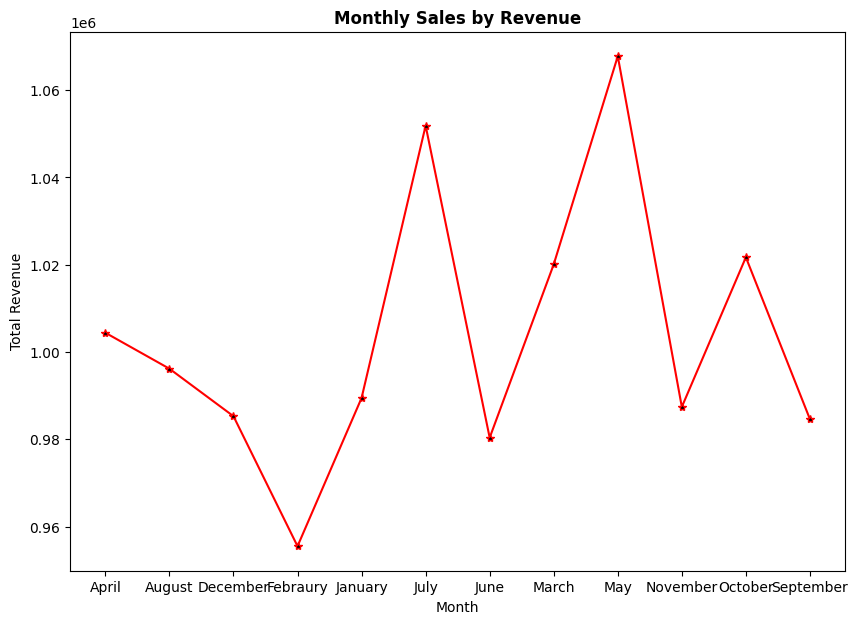

In [ ]:
#Line chart for monthly trend
plt.figure(figsize=(10,7))
plt.plot(monthly_sales,marker='*',mfc='black', color='red')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.title('Monthly Sales by Revenue', fontweight='bold')
plt.show()

Insights:

1. Highest revenue in month May followed by July.

2. Revenue dips in months Febraury, June, November, September.

# Sales Distribution per Order

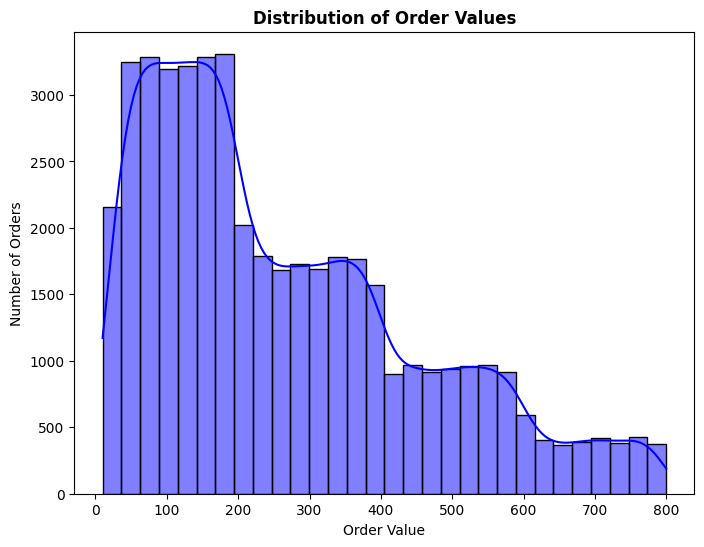

In [ ]:
#Histogram for Sales distribution
plt.figure(figsize=(8,6))
sns.histplot(final_df['Revenue'], bins=30,kde=True, color='Blue', edgecolor='black')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')

plt.title('Distribution of Order Values',fontweight='bold')
plt.show()



Insights:

1. Most of orders are ranging from $ 50 - $250 which means bsuiness is highly driven by regular purchases.
2. The distribution is rightly skewed means count of high order value purchases are low , suggesting upselling or more combo offers.

# Daily Sales Pattern (Day of Week Analysis)

In [ ]:
final_df.columns

Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'month', 'year', 'category',
       'color', 'size', 'season', 'supplier', 'cost_price', 'list_price',
       'store_name', 'region', 'store_size_m2', 'age', 'gender', 'city',
       'email', 'Revenue'],
      dtype='object')

In [ ]:
final_df['day_name']=final_df['date'].dt.day_name()
final_df['day_name']

,day_name
1,Sunday
2,Friday
3,Tuesday
4,Saturday
5,Sunday
...,...
48150,Thursday
48152,Sunday
48153,Thursday
48154,Thursday


In [ ]:
revenue_by_days=final_df.groupby('day_name')['Revenue'].sum().reset_index()
revenue_by_days

,day_name,Revenue
0,Friday,1778357.53
1,Monday,1703579.10
2,Saturday,1756970.89
3,Sunday,1688076.57
4,Thursday,1678253.59
5,Tuesday,1742777.18
6,Wednesday,1696781.37


In [ ]:
days_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday', 'Sunday']

revenue_by_days['day_name']=pd.Categorical(revenue_by_days['day_name'],categories=days_order,ordered=True)

In [ ]:
revenue_by_days=revenue_by_days.sort_values('day_name')
revenue_by_days

,day_name,Revenue
1,Monday,1703579.10
5,Tuesday,1742777.18
6,Wednesday,1696781.37
4,Thursday,1678253.59
0,Friday,1778357.53
2,Saturday,1756970.89
3,Sunday,1688076.57


In [ ]:
import plotly.express as px

In [ ]:
#plotly bar chart for revenue by weekdays
fig=px.bar(revenue_by_days, x='day_name',y='Revenue',labels={'day_name':'Day of Week', 'Revenue':'Total revenue'},color='day_name',title='<b>Total revenue by Day of week</b>')

fig.update_layout(width=700,height=400)
fig.show()

Insights:
1. Friday and Saturday showing slightly higher revenue than other days.

2. All days of week showing similar revenue means not heavily dependent on one specific day.

# Objective 2: Identify Top & Low-Performing Products

### Products with High Quantity but Low Revenue

In [ ]:
final_df.columns

Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'month', 'year', 'category',
       'color', 'size', 'season', 'supplier', 'cost_price', 'list_price',
       'store_name', 'region', 'store_size_m2', 'age', 'gender', 'city',
       'email', 'Revenue', 'day_name'],
      dtype='object')

In [ ]:
product_summary=final_df.groupby('product_id').agg(total_quantity=('quantity','sum'), total_revenue=('Revenue', 'sum')).reset_index()

In [ ]:
product_summary

,product_id,total_quantity,total_revenue
0,P000003,4,177.60
1,P000004,1,68.49
2,P000010,3,166.20
3,P000011,7,822.08
4,P000014,4,711.52
...,...,...,...
29435,P049994,4,744.20
29436,P049995,4,700.60
29437,P049996,3,589.95
29438,P049997,4,543.04


In [ ]:
high_volume=product_summary.sort_values(by='total_quantity', ascending=False)

In [ ]:
high_volumne_low_revenue=high_volume.sort_values(by=['total_quantity','total_revenue'], ascending=[False,True])

In [ ]:
high_volumne_low_revenue.head(10)

,product_id,total_quantity,total_revenue
18699,P031762,22,2139.72
18325,P031170,20,395.40
2268,P003856,20,1176.40
4413,P007482,20,1404.80
13163,P022324,20,3920.00
5489,P009321,19,339.34
25434,P043237,19,576.08
18770,P031883,18,840.06
15755,P026750,18,1318.86
2620,P004452,18,1658.52


In [ ]:
#scatter plot for high volume but low revenue
fig=px.scatter(product_summary, x='total_quantity',
               y='total_revenue',
               title='Product Perfomance: Quantity vs Revenue',
               hover_data = ['product_id'],
               labels={'total_quantity':'Total Quantity sold','total_revenue' : 'Total Revenue'})

fig.show()

Insights:

1. Higher quantity sold products but low revenue contribution(bottom-right area) indicates they are low priced but volume driven,higher customer traffic, lower margins, less profitable but attracts customer.

2. Must increase slightly pricing , bundling strategy, add premium version for higher revenue.


### Products with High Revenue but Low Quantity (Premium Products)

In [ ]:
product_summary

,product_id,total_quantity,total_revenue
0,P000003,4,177.60
1,P000004,1,68.49
2,P000010,3,166.20
3,P000011,7,822.08
4,P000014,4,711.52
...,...,...,...
29435,P049994,4,744.20
29436,P049995,4,700.60
29437,P049996,3,589.95
29438,P049997,4,543.04


In [ ]:
#Threshold for premium product detection
avg_quantity=product_summary['total_quantity'].mean()
avg_revenue=product_summary['total_revenue'].mean()

print(f'Average quantity: {avg_quantity} & Average revenue: {avg_revenue}')

Average quantity: 3.8857676630434783 & Average revenue: 409.1303067255435


In [ ]:
#filter out premium products
premium_products=product_summary[(product_summary['total_revenue']> avg_revenue) & (product_summary['total_quantity'] < avg_quantity)]
premium_products

,product_id,total_quantity,total_revenue
13,P000030,3,550.05
19,P000041,3,418.92
34,P000062,3,448.14
37,P000073,3,524.88
40,P000076,3,497.97
...,...,...,...
29368,P049884,3,532.29
29375,P049895,3,582.33
29386,P049913,3,468.12
29397,P049930,3,550.11


In [ ]:
product_summary['Category_Type']='Normal'

In [ ]:
#conditional assignment
product_summary.loc[(product_summary['total_revenue']> avg_revenue) & (product_summary['total_quantity'] < avg_quantity), 'Category_Type']='Premium'
product_summary

,product_id,total_quantity,total_revenue,Category_Type
0,P000003,4,177.60,Normal
1,P000004,1,68.49,Normal
2,P000010,3,166.20,Normal
3,P000011,7,822.08,Normal
4,P000014,4,711.52,Normal
...,...,...,...,...
29435,P049994,4,744.20,Normal
29436,P049995,4,700.60,Normal
29437,P049996,3,589.95,Premium
29438,P049997,4,543.04,Normal


In [ ]:
#visualise premium products using plotly
fig=px.scatter(product_summary,
               x='total_quantity',
               y='total_revenue',
               color='Category_Type',
               title='Premium product identification',
               hover_data = ['product_id'],
               labels={'total_quantity':'Total Quantity sold','total_revenue' : 'Total Revenue'})

fig.show()

Insights:
1. Red dots denotes Premium Products indicating Revenue drivers & Blue dots are normal products i.e when increase in volume then higher revenue.

2. In this business, medium to higher quantity sold products are giving highest revenue which means business is volume driven than premium driven.

3. Suggesting to introduce more premium product line for higher revenue.

### Product Price Range Performance

In [ ]:
def price_bucket(price):
  if price <= 200:
    return "Low"
  elif price <=400:
    return "Medium"
  else:
    return "High"

In [ ]:
final_df['Price_range']=final_df['Revenue'].apply(price_bucket)

In [ ]:
final_df[['Revenue','Price_range']].head()

,Revenue,Price_range
1,121.79,Low
2,335.88,Medium
3,410.19,High
4,93.24,Low
5,48.06,Low


In [ ]:
price_summary=final_df.groupby('Price_range').agg(total_quantity=('quantity','sum'),total_revenue=('Revenue','sum')).reset_index()

In [ ]:
price_summary

,Price_range,total_quantity,total_revenue
0,High,36223,5636269.27
1,Low,41612,2453538.36
2,Medium,36562,3954988.60


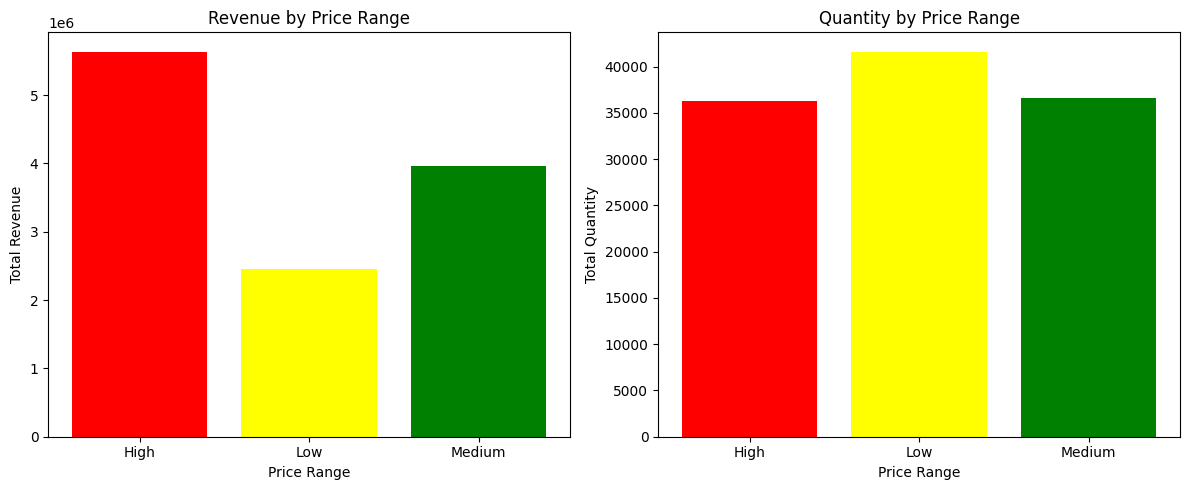

In [ ]:
#Revenue & Quantity by Price Range
fig, axes= plt.subplots(1,2,figsize=(12,5))

#1st plot : revenue by price range
axes[0].bar(price_summary['Price_range'],price_summary['total_revenue'],color=['red','yellow','green'])
axes[0].set_title("Revenue by Price Range")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Total Revenue")

#2nd plot: Quantity plot: quantity by price range
axes[1].bar(price_summary['Price_range'],price_summary['total_quantity'],color=['red','yellow','green'])
axes[1].set_title("Quantity by Price Range")
axes[1].set_xlabel("Price Range")
axes[1].set_ylabel("Total Quantity")

plt.tight_layout()
plt.show()

Insights:

1. Highest price products generates highest revenue even though they quantity sold are less, like premium driven.

2. Low price products sells highest quantity but contributes low revenue, like volume driven, attracts customer traffic.

3. Medium priced products keeps balance between medium quantity and contributing stable revenue.

# Objective 3: Understand Customer Behavior

### 1️⃣ Customer Spending Distribution

In [ ]:
customer_spending=final_df.groupby('customer_id')['Revenue'].sum().reset_index()
customer_spending.rename(columns={'Revenue' : 'Total_spent'},inplace=True)
customer_spending.head()

,customer_id,Total_spent
0,C000001,545.44
1,C000002,950.61
2,C000003,647.87
3,C000005,180.57
4,C000007,34.43


In [ ]:
#plot histogram
fig=px.histogram(customer_spending, x='Total_spent',nbins=30,title='Customer Spending distribution')

fig.update_traces(marker_line_color='black', marker_line_width=1)

fig.update_layout(xaxis_title='Customer_Spending',yaxis_title='Number of customers')

fig.show()

Insights:
1. Most customers are between low to medium spenders indicating business revenue highly relies on these segment of customers.

2. Very small segment of customers belongs to High spending amounts , suggesting business mjust target these segments for loyalty programs and personalised offers  to increase revenue.

## 2️⃣ Repeat vs One-Time Customers

In [ ]:
customers_orders=final_df.groupby('customer_id')['transaction_id'].nunique().reset_index()
customers_orders.rename(columns={'transaction_id': 'num_orders'}, inplace=True)

In [ ]:
customers_orders

,customer_id,num_orders
0,C000001,2
1,C000002,2
2,C000003,4
3,C000005,2
4,C000007,1
...,...,...
20623,C024995,4
20624,C024996,3
20625,C024997,1
20626,C024999,1


In [ ]:
#classify customer type on basis on  numbers of orders
customers_orders['customer_type']=customers_orders['num_orders'].apply(lambda x: 'One-time buyer' if x==1 else 'Repeat-Buyer')


In [ ]:
customers_orders_counts=customers_orders['customer_type'].value_counts().reset_index()
customers_orders_counts.rename(columns={'count':'Count'},inplace=True)
customers_orders_counts

,customer_type,Count
0,Repeat-Buyer,13523
1,One-time buyer,7105


In [ ]:
#plotting BARplot

fig=px.bar(customers_orders_counts,x='customer_type',y='Count',color='customer_type', title=' One time vs Repeat Customers')

fig.show()

Insights:
1. Repeat -Buyers have higher count than one time buyers indicates strong customer retention of Business.

2. Majority of customers are from repeat buyers, Business must focus on loyalty programs and personalized offers to increase further revenue.

## 3️⃣ Customer Spending by Age Group


In [ ]:
bins=[18,25,35,45,55,65,100]
labels=['18-25','26-35','36-45','46-55','56-65','65+']

final_df['age_group']=pd.cut(final_df['age'],bins=bins,labels=labels)


In [ ]:
age_groups_counts=final_df.groupby('age_group')['Revenue'].mean().reset_index()
age_groups_counts.sort_values('Revenue',ascending=False)

/tmp/ipykernel_302/3482334907.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_group,Revenue
2,36-45,267.307107
5,65+,266.625744
1,26-35,266.355601
3,46-55,262.914252
0,18-25,261.848058
4,56-65,259.865113


In [ ]:
#plot line chart
fig=px.line(age_groups_counts, x='age_group',y='Revenue',markers=True,title='Average Customer spending across Age groups')

fig.show()

Insights:
1. Almost all age groups have similar average spending indicates marketing campaigns must target all segments.

2. 36-45 is the highest age group spenders than other contributing highly to Business revenue , suggesting this ssegment must targeted with personalised offers.

# Objective 4: Evaluate Store Performance

### 1️⃣ Average Order Value by Store

In [ ]:
final_df['store_name'].value_counts()

,count
store_name,
Lisbon Flagship,9284
Porto Center,9128
Faro Outlet,9060
Coimbra Boutique,9026
Online,8978
Unknown,178


In [ ]:
aov_store=final_df.groupby('store_name')['Revenue'].mean().reset_index()
aov_store.rename(columns={'Revenue':'revenue_per_store'}, inplace=True)
aov_store.sort_values(by='revenue_per_store', ascending=False)

,store_name,revenue_per_store
1,Faro Outlet,269.044664
0,Coimbra Boutique,264.163228
5,Unknown,264.158483
3,Online,263.680447
2,Lisbon Flagship,261.707048
4,Porto Center,260.613801


In [ ]:
#plot barplot
fig=px.bar(aov_store,x='store_name',y='revenue_per_store',color='store_name',title='AOV by store')
fig.show()

Insights:
1. Faro outlet showing highest revene than others indicating higher customer spending and business must focus on inventory and marketing campaigns.

2. Porto Center generating lowest of all, suggesting business must focus on more on pricing strategies,

## 2️⃣ Profit by Store

In [ ]:
final_df.columns

Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'month', 'year', 'category',
       'color', 'size', 'season', 'supplier', 'cost_price', 'list_price',
       'store_name', 'region', 'store_size_m2', 'age', 'gender', 'city',
       'email', 'Revenue', 'day_name', 'Price_range', 'age_group'],
      dtype='object')

In [ ]:
final_df['Profit']=final_df['Revenue']-final_df['cost_price']

In [ ]:
final_df[['cost_price','Profit']]

,cost_price,Profit
1,71.93,49.86
2,78.59,257.29
3,28.10,382.09
4,65.12,28.12
5,38.07,9.99
...,...,...
48150,39.80,297.79
48152,16.03,394.85
48153,21.09,322.09
48154,48.78,19.24


In [ ]:
profit_store=final_df.groupby('store_name')['Profit'].sum().reset_index()
profit_store.sort_values(by='Profit',ascending=False)

,store_name,Profit
1,Faro Outlet,2049010.71
2,Lisbon Flagship,2035314.84
0,Coimbra Boutique,2001562.78
4,Porto Center,1992900.56
3,Online,1986096.49
5,Unknown,39694.64


In [ ]:
#plot treemap
fig=px.pie(profit_store,names='store_name', values='Profit',title='Profit contribution by Store')
fig.show()

Insights:
1. Faro outlet & Lisbon flagship generating highest profit than other, indicating strongest store performers.
2. Unknown store are comparatively lowest them all means business must focus cost control, pricing strategies and marketing support.

### 3️⃣ Products Sold per Store (Product Variety)

In [ ]:
store_product_variety=final_df.groupby('store_name')['product_id'].nunique().reset_index()

In [ ]:
store_product_variety.rename(columns={'product_id':'No_unique_products'},inplace=True)
store_product_variety.sort_values(by='No_unique_products', ascending=False)

,store_name,No_unique_products
2,Lisbon Flagship,8483
4,Porto Center,8292
1,Faro Outlet,8246
0,Coimbra Boutique,8244
3,Online,8211
5,Unknown,177


Insights:
1. Lisbon Flagship have highest variety of products which can attract customers and increase in sales.

2. Unknown stores might have missing information and business must focus such expanding inventory for stores with low variety products to increase customer choices.

### 4️⃣ Monthly Sales Trend for Top Stores

In [ ]:
final_df['month_number']=final_df['date'].dt.month

In [ ]:
final_df['month_name']=final_df['date'].dt.month_name()#new month name column with dt.month_name() function

In [ ]:
monthly_trend_store= final_df.groupby(['month_number','month_name','store_name'])['Revenue'].sum().reset_index()
monthly_trend_store=monthly_trend_store.sort_values(by='month_number')
print(monthly_trend_store.head(10))

   month_number month_name        store_name    Revenue
0             1    January  Coimbra Boutique  205520.27
1             1    January       Faro Outlet  195656.92
2             1    January   Lisbon Flagship  199902.57
3             1    January            Online  202035.36
4             1    January      Porto Center  182220.84
5             1    January           Unknown    4147.98
6             2   February  Coimbra Boutique  212866.78
7             2   February       Faro Outlet  184408.93
8             2   February   Lisbon Flagship  186530.27
9             2   February            Online  177875.52


In [ ]:
#ploting line chart

fig=px.line(monthly_trend_store,x='month_name',y='Revenue',color='store_name', title='Monthly Sales Trend by Store')
fig.show()

Insights:
1. Most stores showing almostb similar sales trend ranging between 180 to 250K , indicating consistent stores perfomance.

2. porter center showing peak months in May month and Lisnon flagship showing peak months in October , indicating seasonal demand or successful promotional periods.

3. 'unknown' store generates lowest sales trend than others indicates missing info or minor sales channels.

# **Business Conclusion**

* The business is performing strongly with $12M+ revenue and high transaction volume, indicating solid customer demand and market presence.
* Sales are driven by a mix of volume products (low price, high quantity) and premium products (high revenue, low quantity), suggesting a balanced pricing strategy is crucial.
* A large portion of revenue comes from repeat customers, highlighting good customer retention, but there is an opportunity to increase loyalty programs for high-value customers.
* Mid-age groups (26–45) contribute slightly higher spending, but overall spending is fairly consistent across all age groups, meaning marketing should target broad customer segments rather than a niche group.
* Top-performing stores (like flagship and outlet stores) generate higher revenue and profit, while weaker stores need pricing, inventory, or marketing improvements.
* Sales trends show seasonality (peak in May/July) and consistent weekly performance, helping businesses plan inventory and promotions better.
Some products show high quantity but low revenue, indicating the need for pricing optimization, bundling, or upselling strategies.